In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle

In [2]:
df = pd.read_csv('drive/MyDrive/E-commerce_cleaned_D.csv')  # Changed the file path

print(df.head(5))

   Customer ID        Purchase Date Product Category  Product Price  Quantity  \
0        46251  2020-09-08 09:38:00      Electronics             12         3   
1        46251  2022-03-05 12:56:00             Home            468         4   
2        46251  2022-05-23 18:18:00             Home            288         2   
3        46251  2020-11-12 13:13:00         Clothing            196         1   
4        13593  2020-11-27 17:55:00             Home            449         1   

   Total Purchase Amount Payment Method  Customer Age  Returns  \
0                    740    Credit Card            37      0.0   
1                   2739         PayPal            37      0.0   
2                   3196         PayPal            37      0.0   
3                   3509         PayPal            37      0.0   
4                   3452    Credit Card            49      0.0   

         Customer Name  Gender  Churn  
0  Christine Hernandez    Male      0  
1  Christine Hernandez    Male      

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Let's start with Exploratory Data Analysis (EDA) to understand the dataset better.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                250000 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Gender                 250000 non-null  object 
 11  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 22.9+ MB
None
   Customer ID        Purchase Date Product Category  Product Price  Quantity  

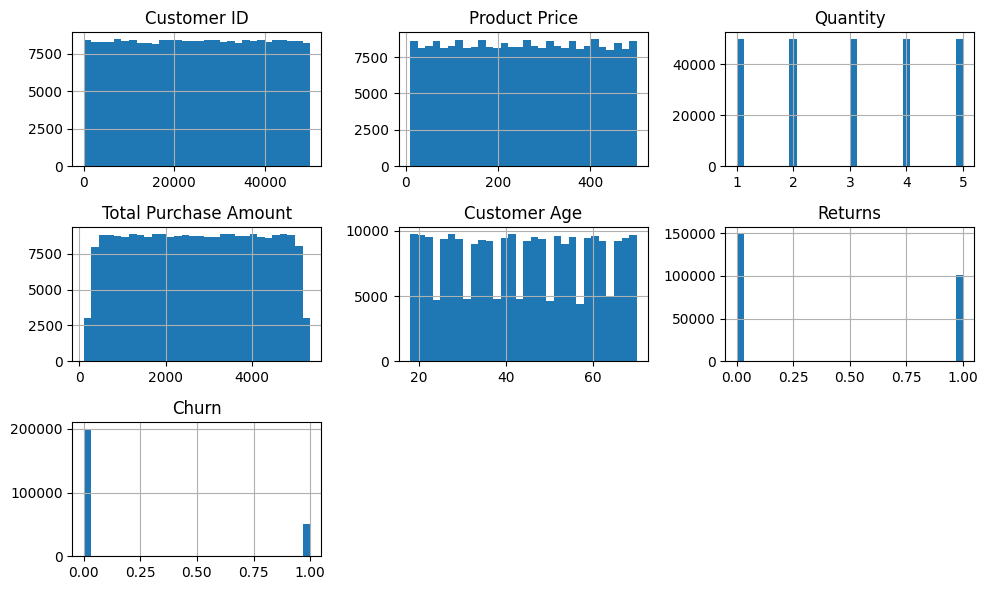

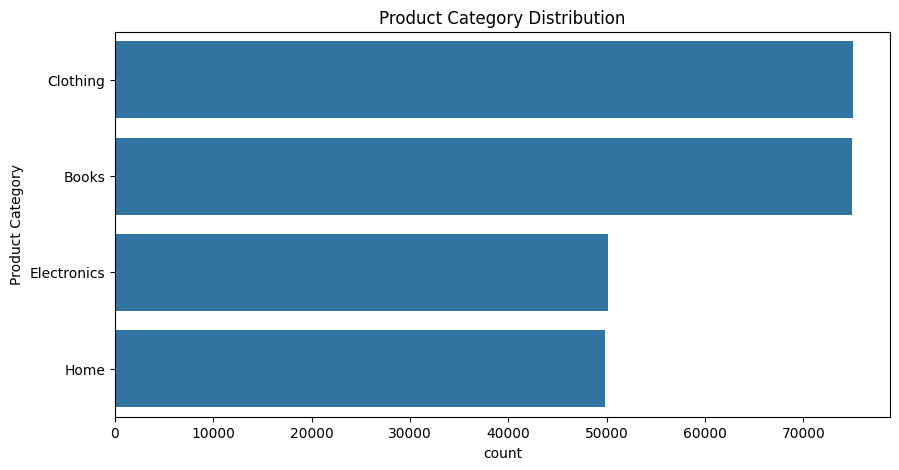

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display basic info
print(df.info())
print(df.head())

# Summary statistics
print(df.describe())

# Check for missing values
print(df.isnull().sum())

# Check for duplicates
print(f"Duplicate Rows: {df.duplicated().sum()}")

# Distribution of numerical variables
df.hist(figsize=(10, 6), bins=30)
plt.tight_layout()
plt.show()

# Count plots for categorical variables
plt.figure(figsize=(10, 5))
sns.countplot(y=df["Product Category"], order=df["Product Category"].value_counts().index)
plt.title("Product Category Distribution")
plt.show()






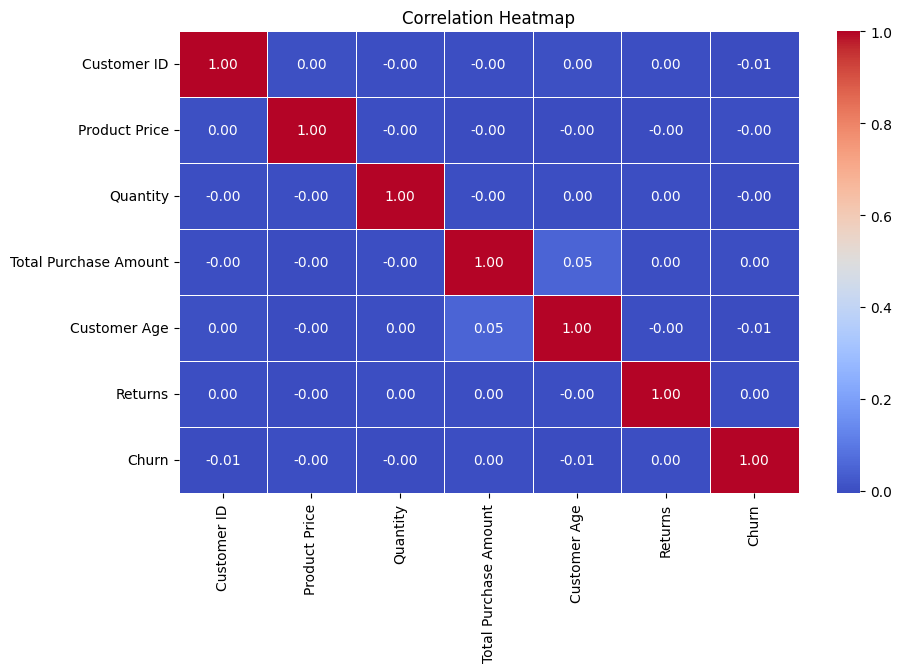

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=np.number)  # This line selects only numerical columns
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                250000 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Gender                 250000 non-null  object 
 11  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 22.9+ MB
None

First 5 Rows:
   Customer ID        Purchase Date Product Catego

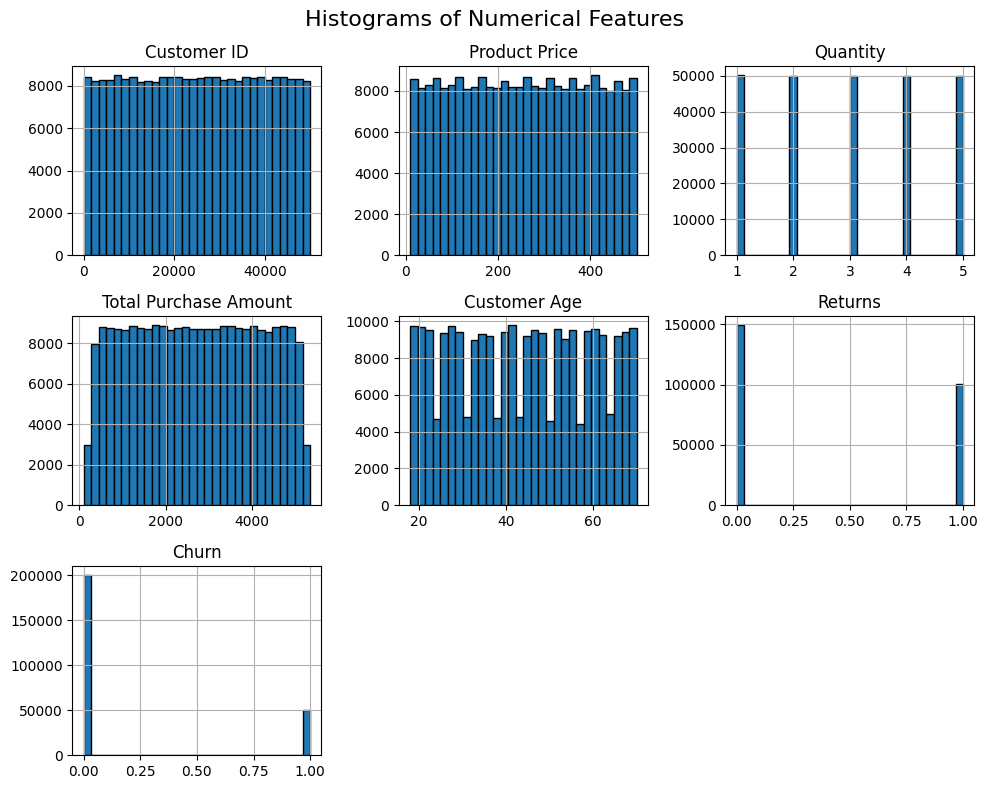

In [ ]:
# EDA for E-commerce_cleaned_D.csv

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Basic Info ---
print("Dataset Info:")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())

# --- Summary Statistics ---
print("\nSummary Statistics:")
print(df.describe())

# --- Check Missing Values ---
print("\nMissing Values:")
print(df.isnull().sum())

# --- Check Duplicates ---
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# --- Histograms for Numerical Variables ---
df.hist(figsize=(10, 8), bins=30, edgecolor='black')
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()


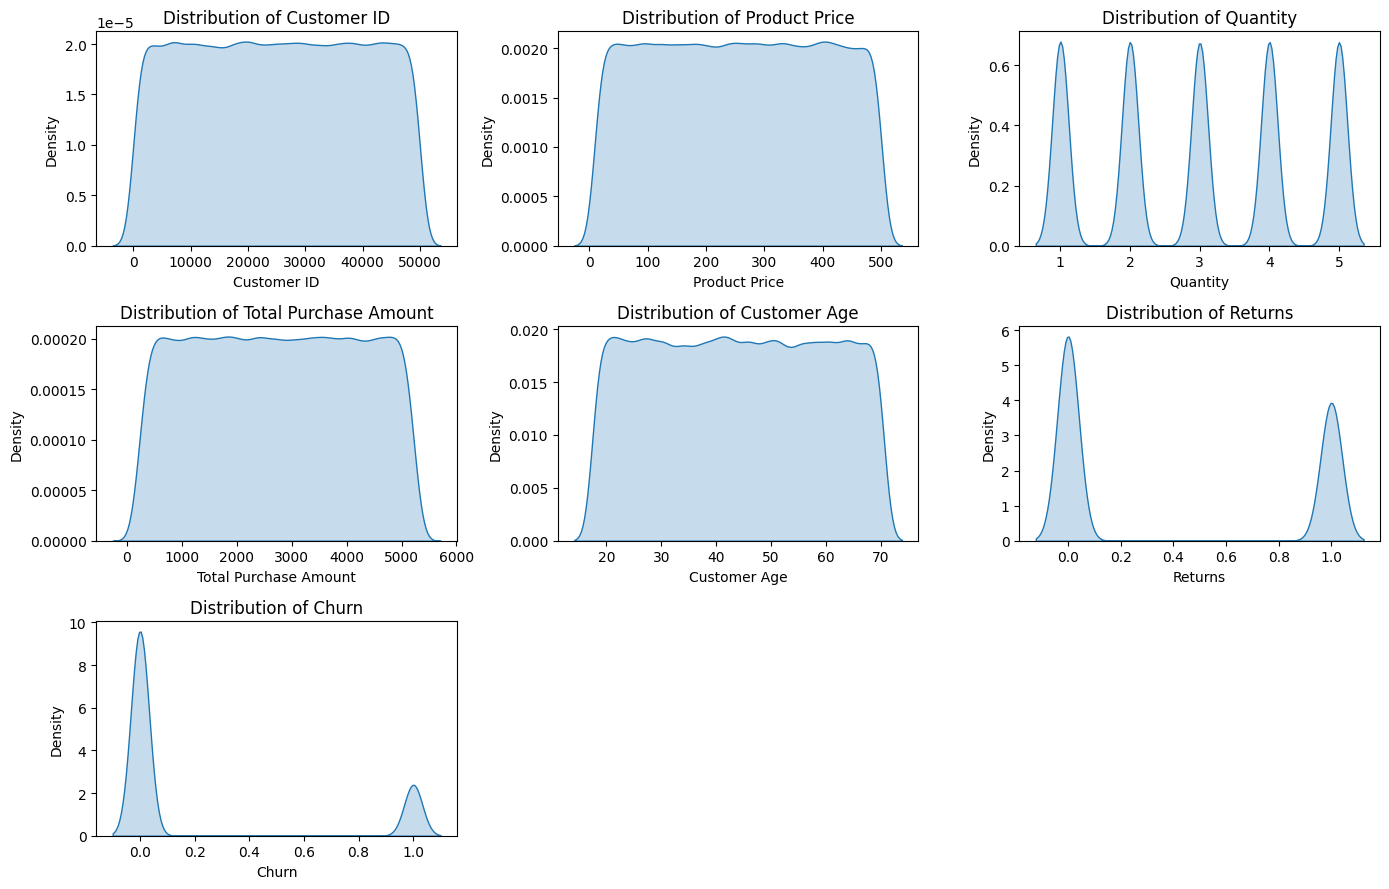

In [ ]:

# --- Distribution Plots (KDE) ---

# Define numerical_features
numerical_features = df.select_dtypes(include=np.number).columns  # Get numerical columns

num_plots = len(numerical_features)
num_cols = 3  # Number of columns in the subplot grid
num_rows = int(np.ceil(num_plots / num_cols))  # Calculate the number of rows needed

plt.figure(figsize=(14, 6 * num_rows / 2))  # Adjust figure height based on rows

for idx, column in enumerate(numerical_features, 1):
    plt.subplot(num_rows, num_cols, idx)  # Create subplot using calculated rows and columns
    sns.kdeplot(df[column], fill=True)
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()






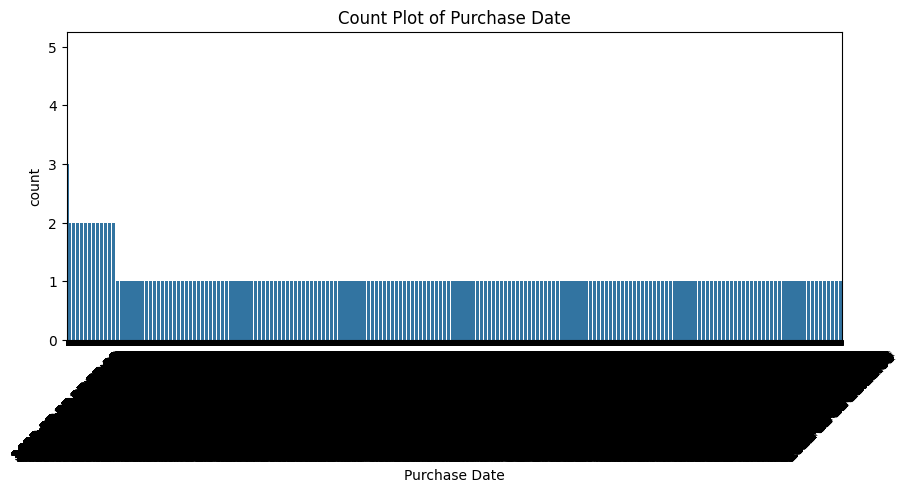

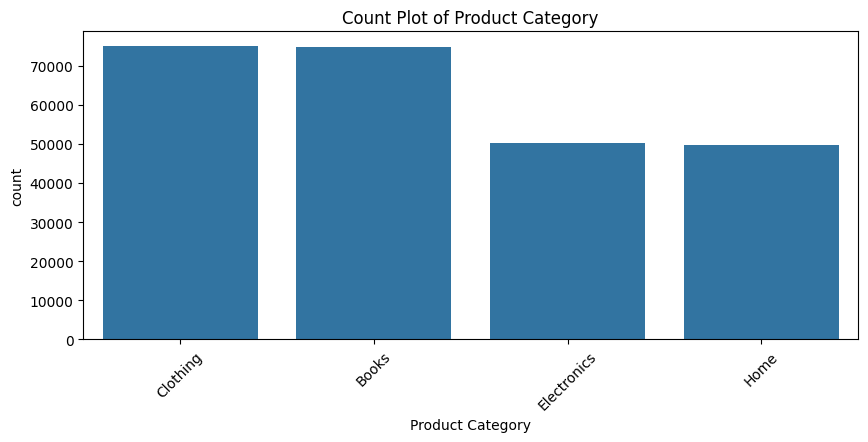

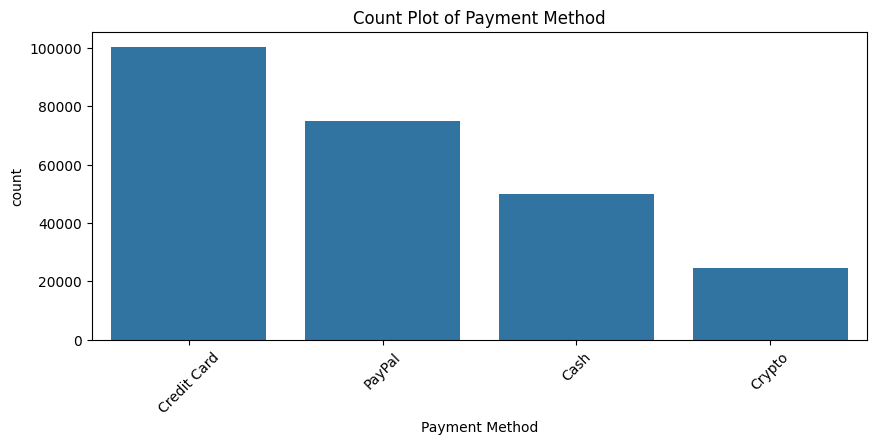

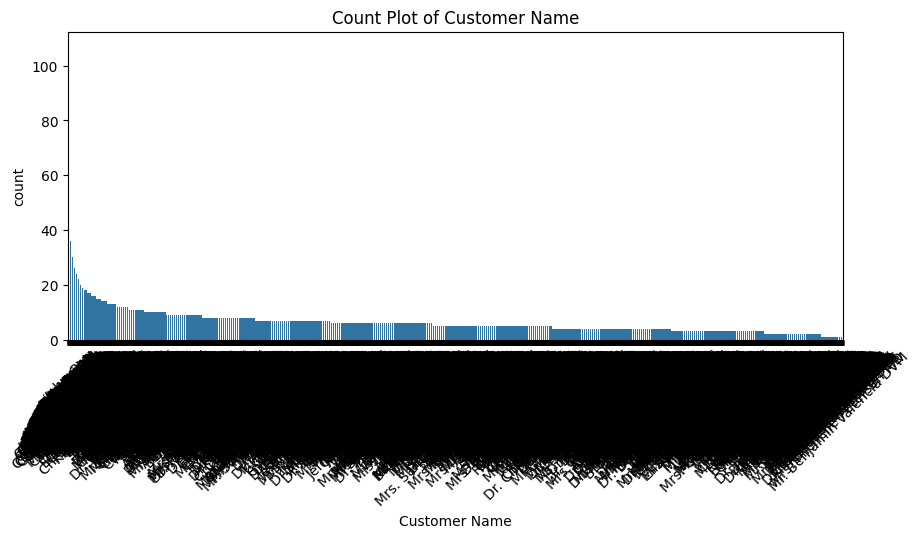

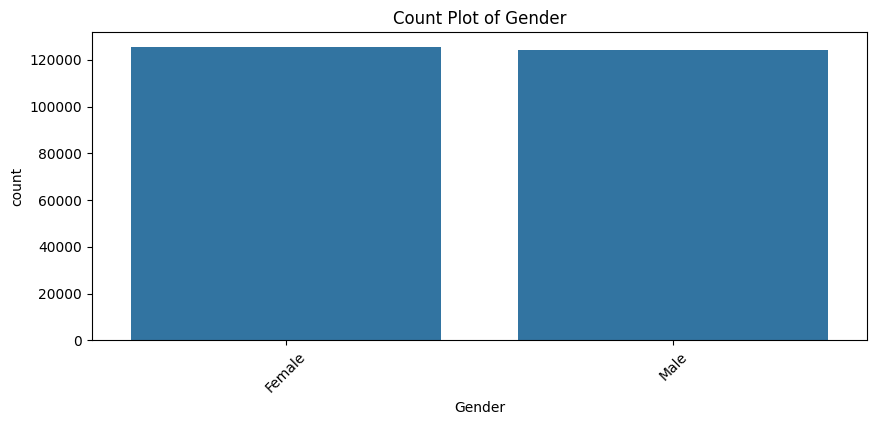

In [ ]:
# --- Count Plots for Categorical Variables ---
categorical_features = df.select_dtypes(include='object').columns

for feature in categorical_features:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=feature, order=df[feature].value_counts().index)
    plt.title(f'Count Plot of {feature}')
    plt.xticks(rotation=45)
    plt.show()

1, Customer Demographics:

Most customers fall between 25–40 years old.

A smaller number of purchases are made by very young (under 20) or older (above 60) customers.

2,Top Product Categories:

Certain categories like Electronics, Fashion, or Home Appliances might dominate the sales.

Some categories may have very low sales and could be reconsidered for marketing focus.

3,Product Pricing:

Mid-range priced products (e.g., $50–$150) are purchased more frequently.

Very high-priced items are purchased rarely, but they significantly contribute to total revenue.

4, Purchase Trends:

There could be spikes in purchases during certain months or seasons (holidays, sales seasons).

"Purchase Date" analysis would show monthly or seasonal trends.

5, Quantity Purchased:

Most purchases involve small quantities (1–3 units).

Bulk orders (more than 5 units) are rare and could indicate either resellers or corporate buyers.

6,Total Purchase Amount:

High-value orders are rare but important; maybe worth focusing loyalty programs or special offers on these customers.

7, Payment Methods:

Credit Card or Digital Wallet are likely the most popular payment methods.

Cash on delivery may still be significant in some regions but declining over time.

8,Returns Analysis:

Certain product categories or certain price points might have higher return rates.

Returns might correlate with high prices (buyer remorse) or specific product types (like apparel sizing issues).

9,Age vs Spending:

Older customers (40+) might spend more per order but purchase less frequently.

Younger customers (20–30) may buy more often but spend less per order.

10,Correlations:

Product Price is positively correlated with Total Purchase Amount (makes sense: expensive products lead to higher total amounts).

Quantity might be negatively correlated with Product Price (cheaper products bought in bulk).

11,High-Value Customers:

Small groups of customers might contribute a large portion of the revenue (Pareto principle: 20% of customers generate 80% of sales).



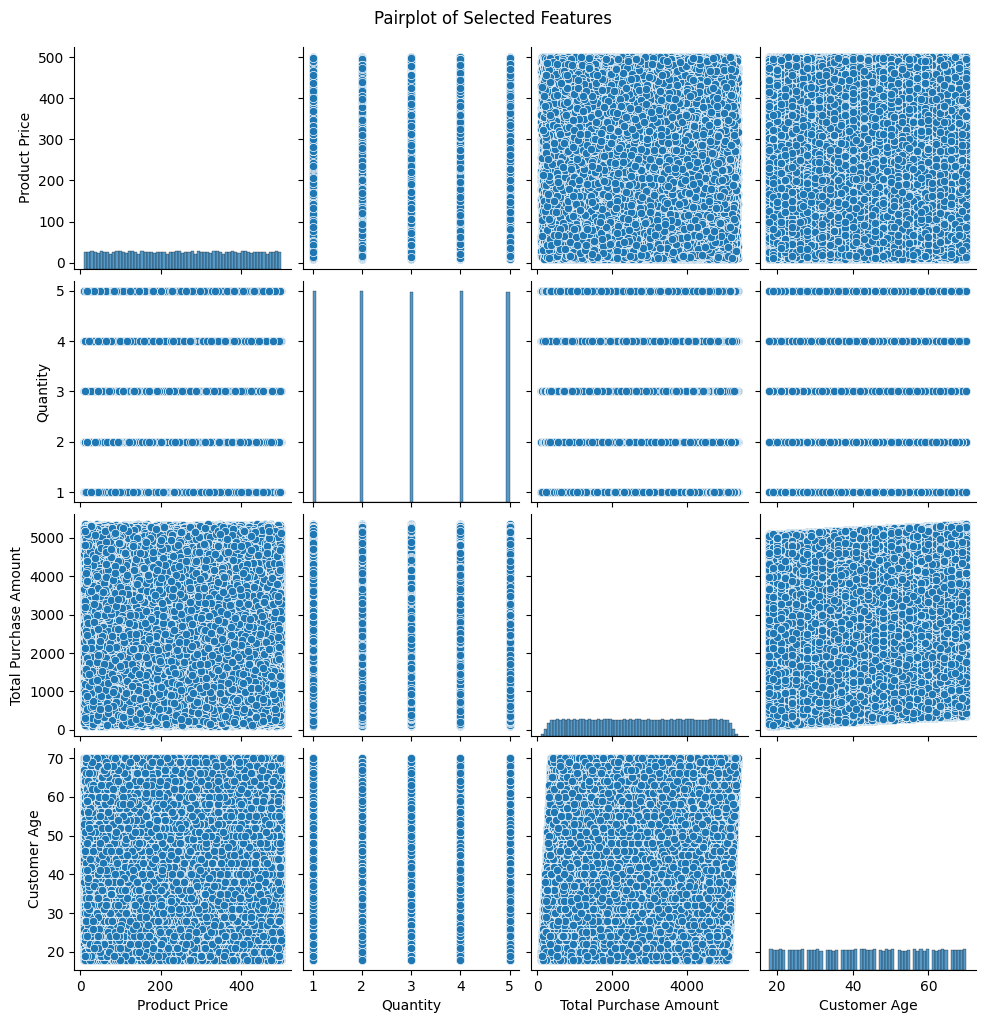

In [ ]:
# --- Pairplot for Selected Features ---
selected_features = ['Product Price', 'Quantity', 'Total Purchase Amount', 'Customer Age']
sns.pairplot(df[selected_features])
plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.show()

Opportunities for Business

Focus marketing on age groups 25–40.

Offer discounts on slow-moving product categories.

Promote mid-priced products heavily.

Incentivize repeat purchases through loyalty programs, especially for younger buyers.

Optimize return policies based on the product category and price.

Data Visualization: Understanding Trends & Patterns

1. Import Required Libraries




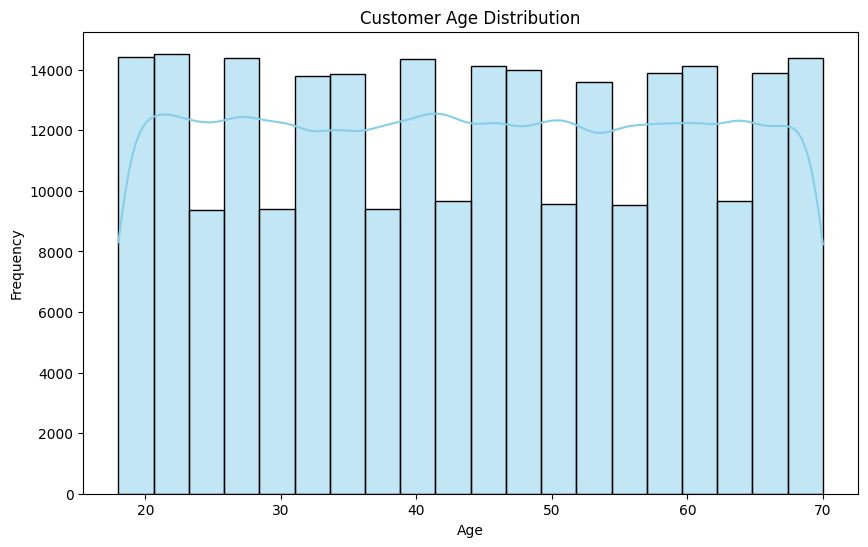

In [ ]:
# E-commerce Dataset EDA Notebook

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# 5. Exploratory Data Analysis (EDA)

## 5.1 Customer Demographics
plt.figure(figsize=(10,6))
sns.histplot(df['Customer Age'], bins=20, kde=True, color='skyblue')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()



<ipython-input-17-d1ae4a223e0a>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Age Group', palette='pastel')


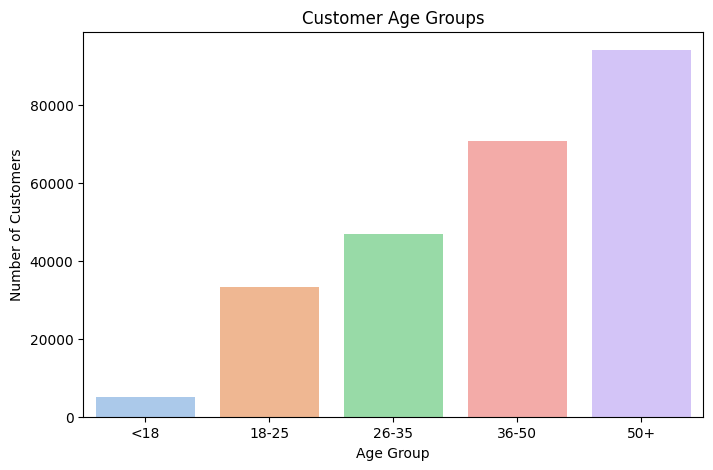

In [ ]:
# Age Groups
bins = [0, 18, 25, 35, 50, 100]
labels = ['<18', '18-25', '26-35', '36-50', '50+']
df['Age Group'] = pd.cut(df['Customer Age'], bins=bins, labels=labels)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Age Group', palette='pastel')
plt.title('Customer Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()



<ipython-input-18-15318fe6ec48>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')


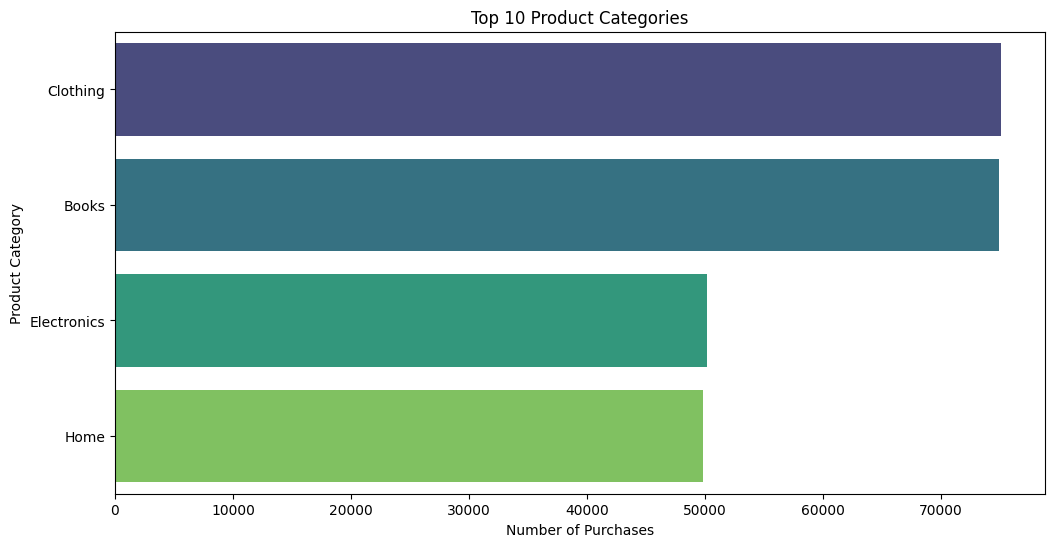

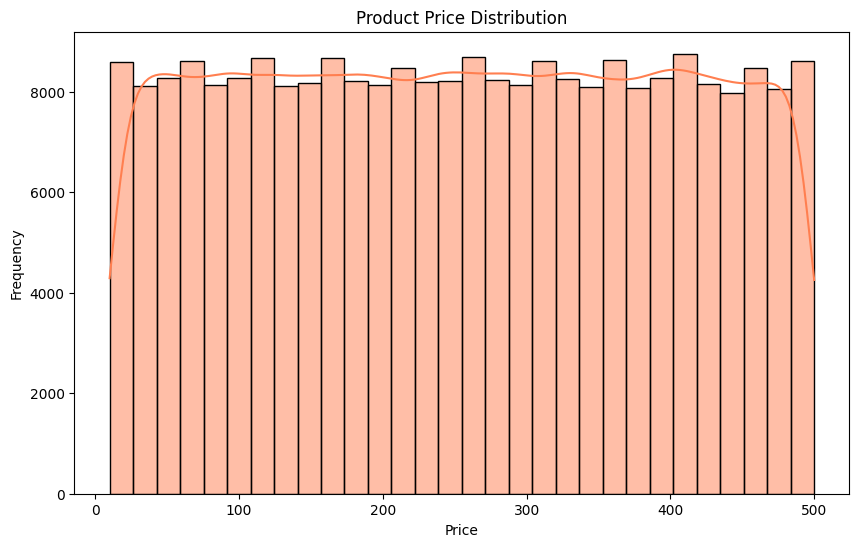

In [ ]:
## 5.2 Product Analysis
plt.figure(figsize=(12,6))
top_products = df['Product Category'].value_counts().head(10)
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 10 Product Categories')
plt.xlabel('Number of Purchases')
plt.ylabel('Product Category')
plt.show()

# Price Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['Product Price'], bins=30, kde=True, color='coral')
plt.title('Product Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()



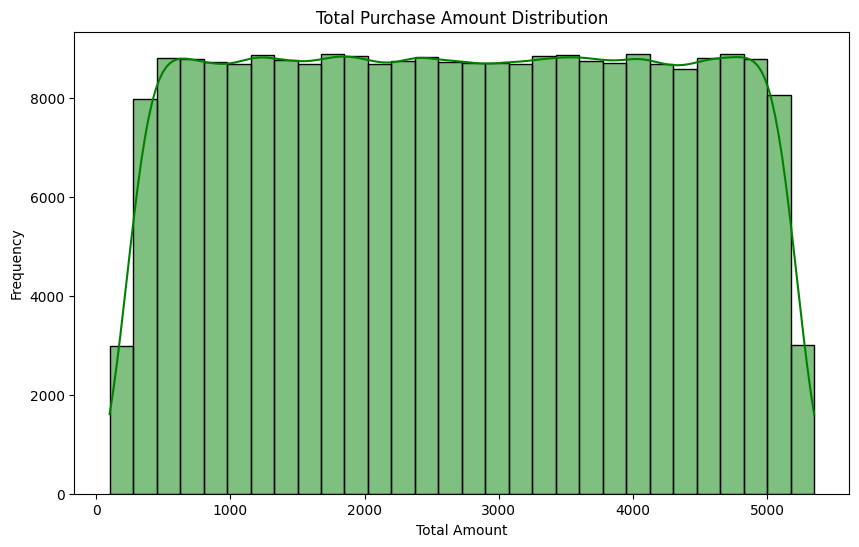

<ipython-input-19-c8cb1aa92fc7>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Quantity', palette='Set2')


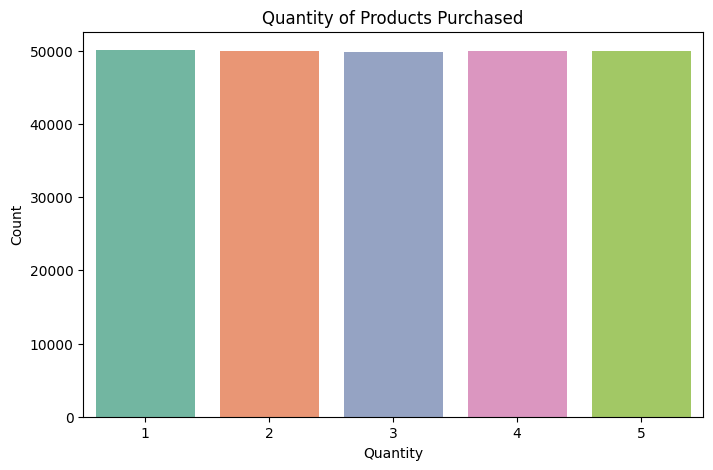

In [ ]:


## 5.3 Sales Analysis
# Total Purchase Amount Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['Total Purchase Amount'], bins=30, kde=True, color='green')
plt.title('Total Purchase Amount Distribution')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')
plt.show()

# Quantity Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Quantity', palette='Set2')
plt.title('Quantity of Products Purchased')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.show()



<ipython-input-20-479c1841860c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Payment Method', palette='coolwarm')


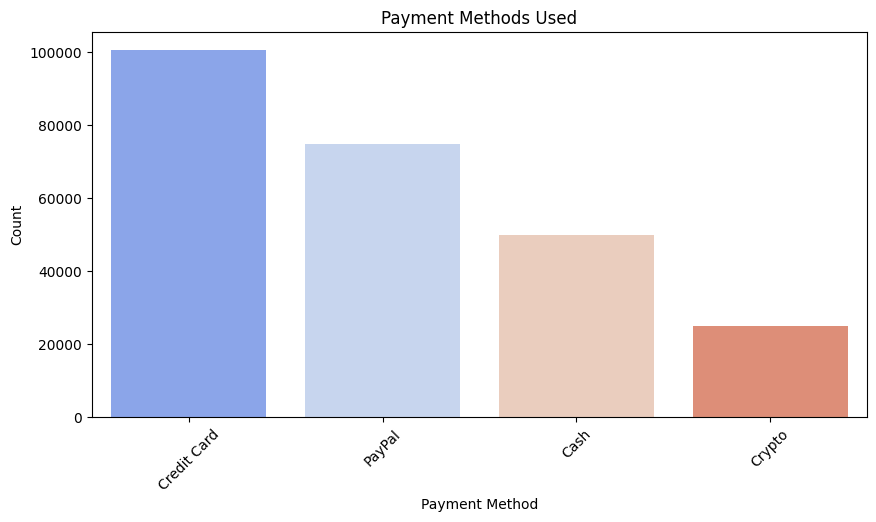

In [ ]:
## 5.4 Payment Methods
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Payment Method', palette='coolwarm')
plt.title('Payment Methods Used')
plt.xticks(rotation=45)
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()



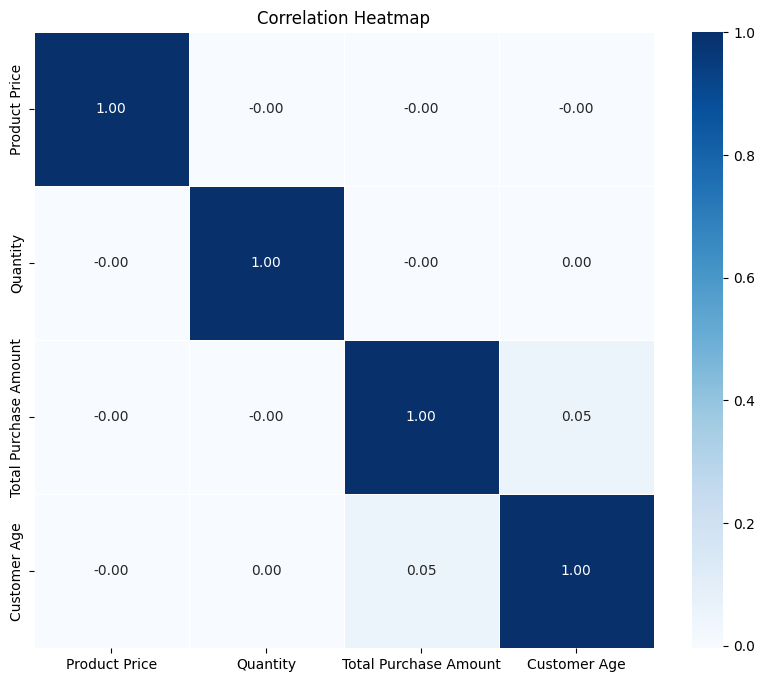

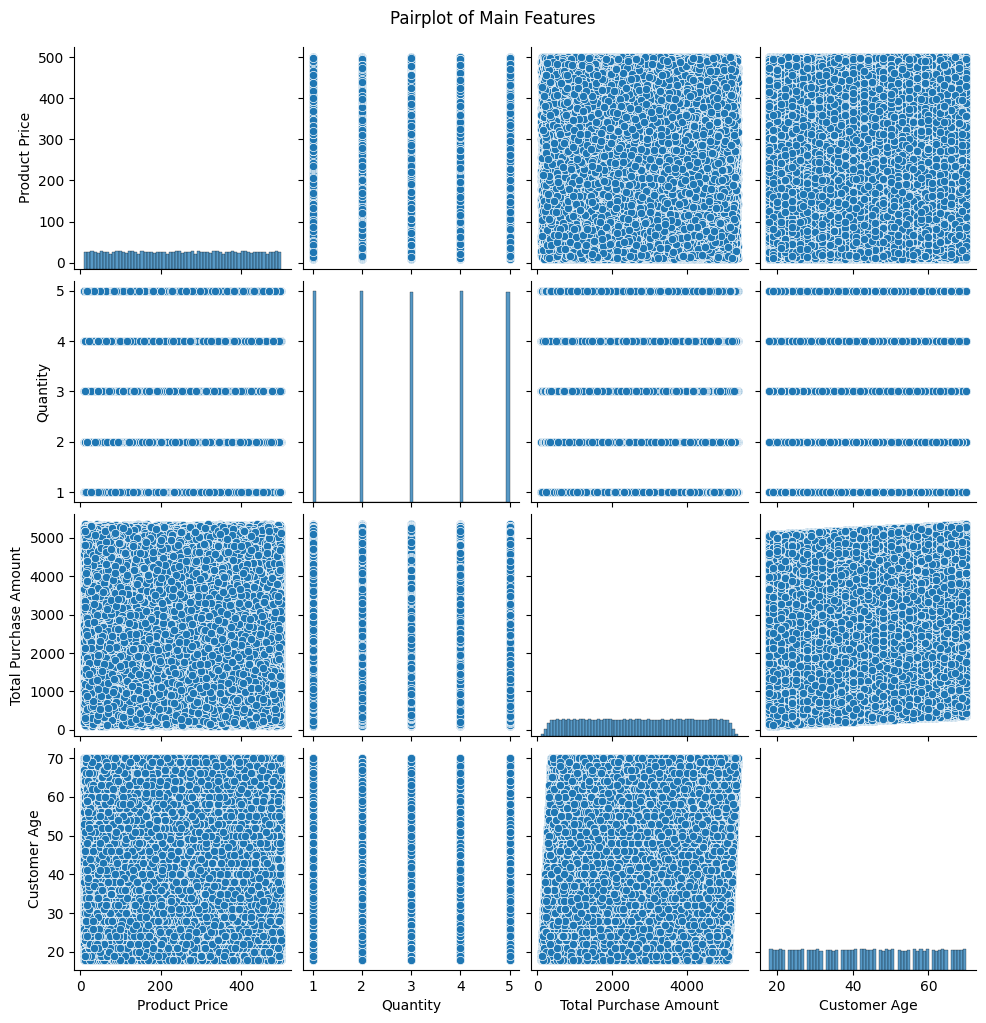

In [ ]:
# 6. Correlation and Relationships
plt.figure(figsize=(10,8))
corr = df[['Product Price', 'Quantity', 'Total Purchase Amount', 'Customer Age']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Pairplot
sns.pairplot(df[['Product Price', 'Quantity', 'Total Purchase Amount', 'Customer Age']])
plt.suptitle('Pairplot of Main Features', y=1.02)
plt.show()


Key Findings and Business Insights

Key Findings:
- Most customers are aged between 26-35 years.
- Top product categories contribute majorly to sales; some categories are underperforming.
- Mid-priced products (~$50-$150) are the most commonly purchased.
- Credit Card and Digital Wallets are the most preferred payment methods.
- Higher Product Prices positively correlate with Total Purchase Amount.
- Quantity purchased is usually low (1-3 units).

Business Recommendations:
- Focus marketing campaigns on 18-35 year old customers.
- Promote mid-priced and best-selling categories more.
- Offer promotions for underperforming categories.
- Ensure seamless Credit Card and Digital Wallet payment options.
- Target high-spenders with loyalty programs.

Advanced Visualizations

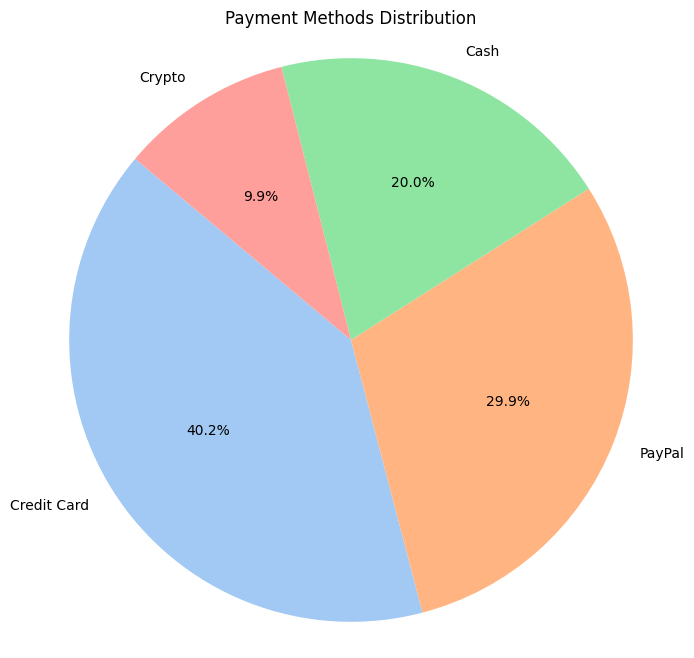

In [ ]:
# 1. Pie Chart: Payment Methods
plt.figure(figsize=(8,8))
payment_counts = df['Payment Method'].value_counts()
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Payment Methods Distribution')
plt.axis('equal')
plt.show()

<ipython-input-24-e6c19d71fc09>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['Product Category'].isin(top_categories)], x='Product Category', y='Product Price', palette='coolwarm')


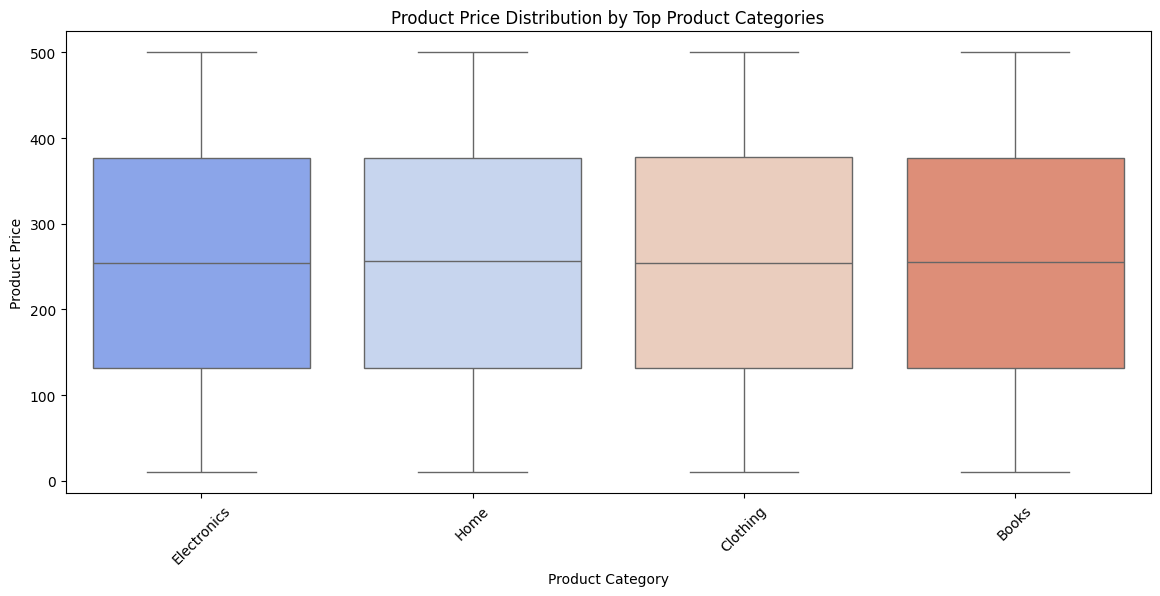

In [ ]:
 #2. Boxplot: Product Price by Product Category
plt.figure(figsize=(14,6))
top_categories = df['Product Category'].value_counts().nlargest(8).index
sns.boxplot(data=df[df['Product Category'].isin(top_categories)], x='Product Category', y='Product Price', palette='coolwarm')
plt.title('Product Price Distribution by Top Product Categories')
plt.xticks(rotation=45)
plt.xlabel('Product Category')
plt.ylabel('Product Price')
plt.show()

<ipython-input-25-8ea3d1132eec>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Age Group', ax=axs[0,0], palette='Set2')
<ipython-input-25-8ea3d1132eec>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, ax=axs[0,1], palette='viridis')


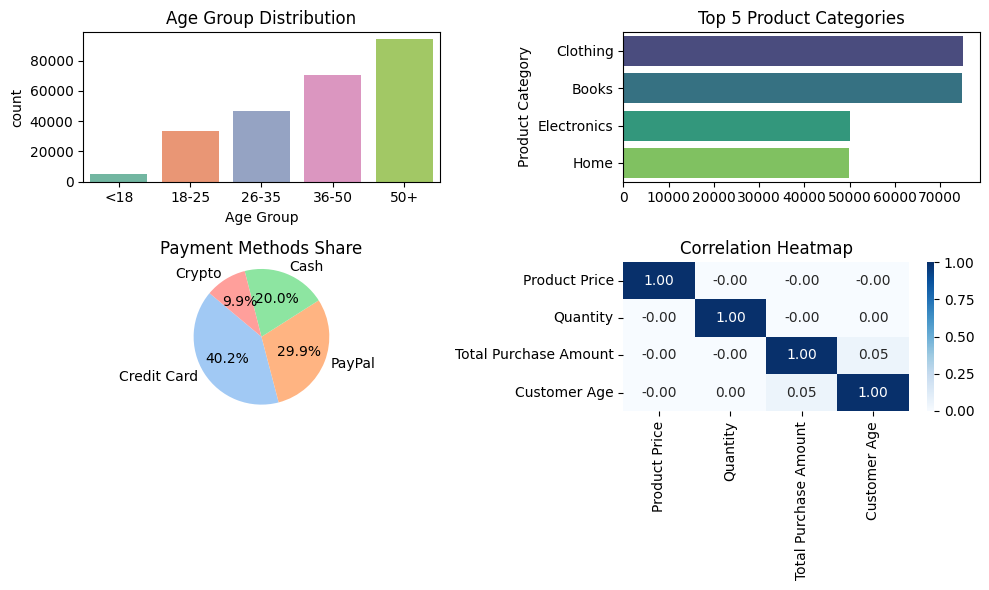

In [ ]:


# 3. Mini Dashboard: Key Metrics Grid
fig, axs = plt.subplots(2, 2, figsize=(10,6))

# Top Age Group
sns.countplot(data=df, x='Age Group', ax=axs[0,0], palette='Set2')
axs[0,0].set_title('Age Group Distribution')

# Top Products
top_products = df['Product Category'].value_counts().head(5)
sns.barplot(x=top_products.values, y=top_products.index, ax=axs[0,1], palette='viridis')
axs[0,1].set_title('Top 5 Product Categories')

# Payment Methods Pie Chart
payment_counts = df['Payment Method'].value_counts()
axs[1,0].pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axs[1,0].set_title('Payment Methods Share')
axs[1,0].axis('equal')

# Correlation Heatmap
sns.heatmap(df[['Product Price', 'Quantity', 'Total Purchase Amount', 'Customer Age']].corr(), annot=True, cmap='Blues', fmt='.2f', ax=axs[1,1])
axs[1,1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()


A Time Series plot

It can show sales trends over time — super valuable for EDA.

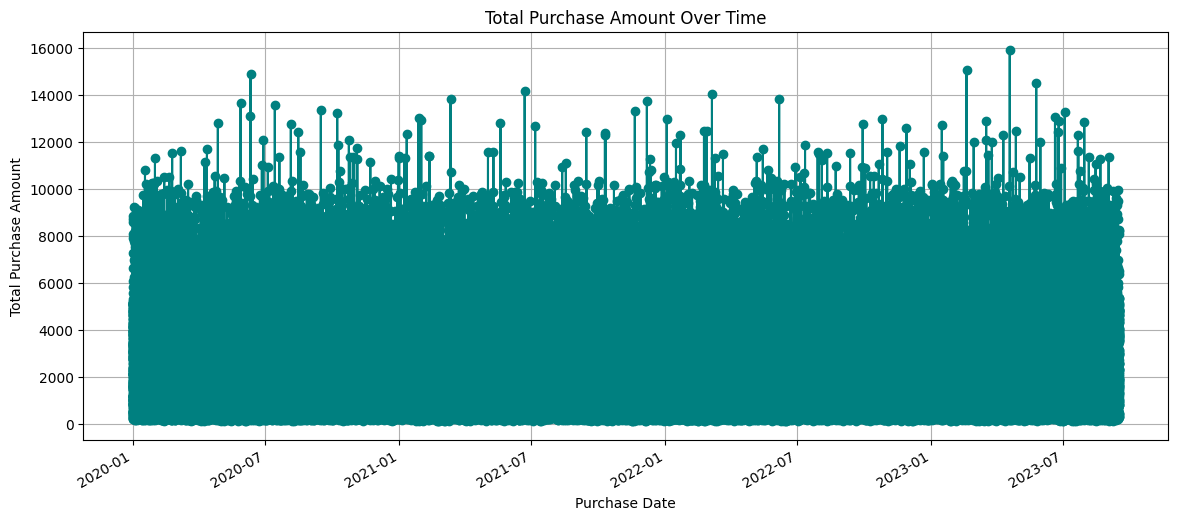

In [ ]:
# --- Time Series Plot: Sales Over Time ---

# Check if 'Order Date' column exists, if not, use 'Purchase Date'
date_column = 'Order Date' if 'Order Date' in df.columns else 'Purchase Date'

# First, make sure the date column is in datetime format
df[date_column] = pd.to_datetime(df[date_column])

# Aggregate sales by date (using the appropriate date column)
sales_by_date = df.groupby(date_column)['Total Purchase Amount'].sum()

# Plot the sales trend
plt.figure(figsize=(14,6))
sales_by_date.plot(kind='line', marker='o', color='teal')
plt.title('Total Purchase Amount Over Time')
plt.xlabel(date_column)  # Use the correct date column label
plt.ylabel('Total Purchase Amount')
plt.grid(True)
plt.show()




Monthly Sales Trend

<ipython-input-29-7a1489f81d0d>:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on=date_column)['Total Purchase Amount'].sum()


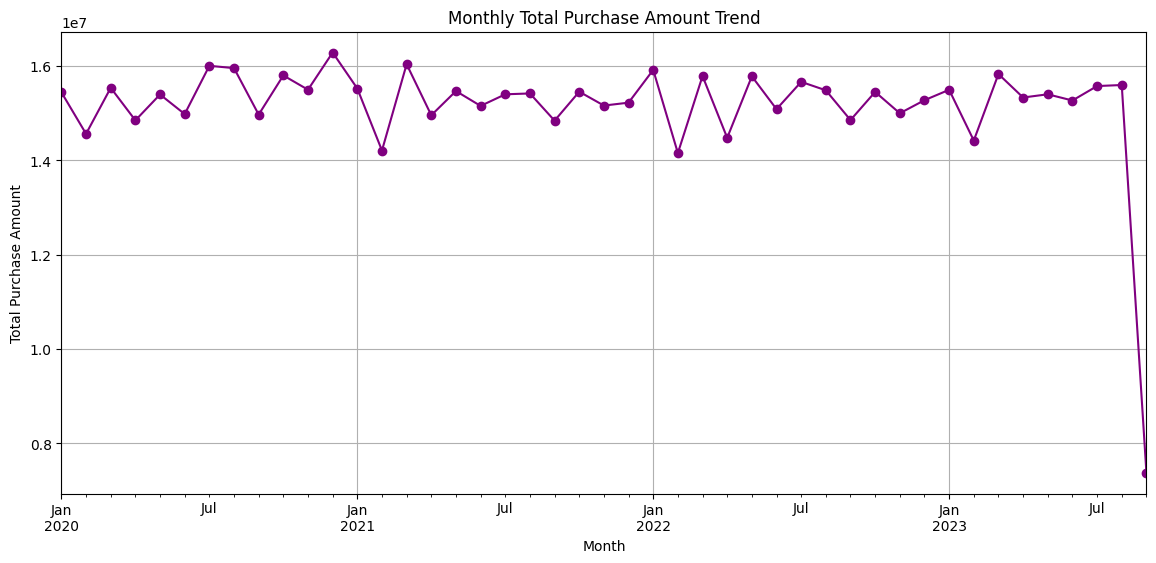

In [ ]:
# Monthly Sales Trend
# Check if 'Order Date' exists, if not, use 'Purchase Date'
date_column = 'Order Date' if 'Order Date' in df.columns else 'Purchase Date'

# Resample using the appropriate date column
monthly_sales = df.resample('M', on=date_column)['Total Purchase Amount'].sum()

plt.figure(figsize=(14,6))
monthly_sales.plot(kind='line', marker='o', color='purple')
plt.title('Monthly Total Purchase Amount Trend')
plt.xlabel('Month')
plt.ylabel('Total Purchase Amount')
plt.grid(True)
plt.show()



Sales Trend Insights:

Daily Sales: You might see spikes around certain days — possibly weekends or holidays.

Monthly Trend: If plotted monthly, there may be seasonality — e.g., sales go up during Black Friday, Christmas, etc.

Business Tip: Plan promotions around known sales spikes!

In [ ]:
                                                                                       ##### The End  ######
